<a href="https://colab.research.google.com/github/synexiaofficial-byte/crowd-navi/blob/main/lecture6_ipynb_%E3%81%AE%E3%82%B3%E3%83%94%E3%83%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

np.random.seed(0)

普通のランダムウォーク

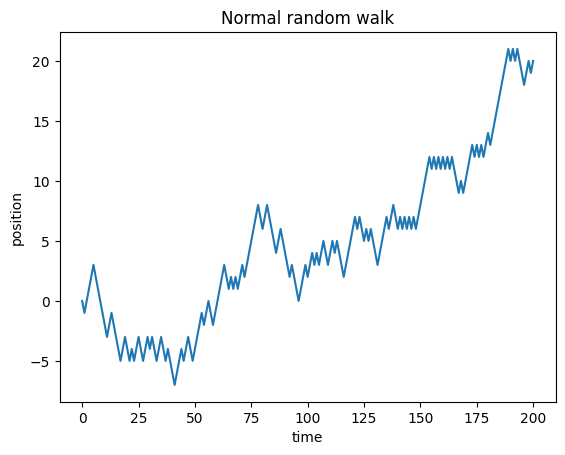

In [ ]:
T = 200

x = 0
x_normal = [x]
steps_normal = []

for t in range(T):
    step = np.random.choice([-1, 1])
    x += step

    steps_normal.append(step)
    x_normal.append(x)

plt.plot(x_normal)
plt.xlabel("time")
plt.ylabel("position")
plt.title("Normal random walk")
plt.show()

慣性付きランダムウォーク

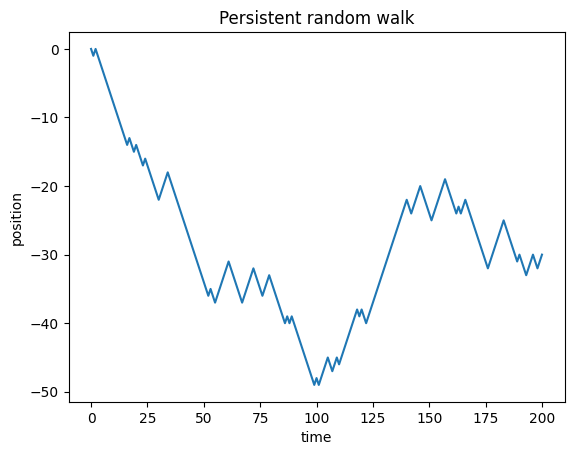

In [ ]:
T = 200
p_same = 0.8  # 前回と同じ方向に進む確率

x = 0
prev_step = np.random.choice([-1, 1])

x_persistent = [x]
steps_persistent = []

for t in range(T):
    if np.random.rand() < p_same:
        step = prev_step
    else:
        step = -prev_step

    x += step

    steps_persistent.append(step)
    x_persistent.append(x)
    prev_step = step

plt.plot(x_persistent)
plt.xlabel("time")
plt.ylabel("position")
plt.title("Persistent random walk")
plt.show()

軌道を比較する

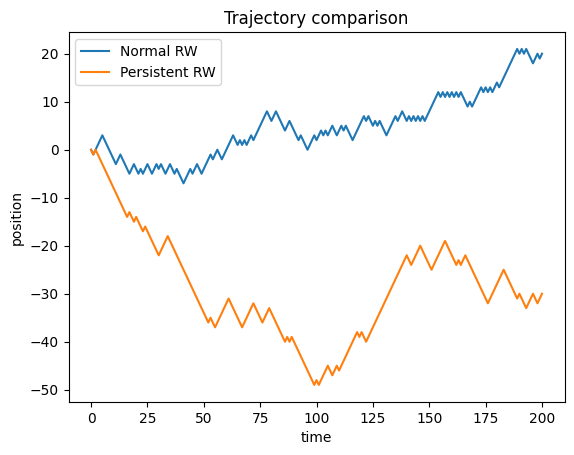

In [ ]:
plt.plot(x_normal, label="Normal RW")
plt.plot(x_persistent, label="Persistent RW")
plt.xlabel("time")
plt.ylabel("position")
plt.title("Trajectory comparison")
plt.legend()
plt.show()

多数回試行して最終位置の分布をみる

In [ ]:
def normal_random_walk(T):
    x = 0
    for t in range(T):
        step = np.random.choice([-1, 1])
        x += step
    return x


def persistent_random_walk(T, p_same=0.8):
    x = 0
    prev_step = np.random.choice([-1, 1])

    for t in range(T):
        if np.random.rand() < p_same:
            step = prev_step
        else:
            step = -prev_step

        x += step
        prev_step = step

    return x

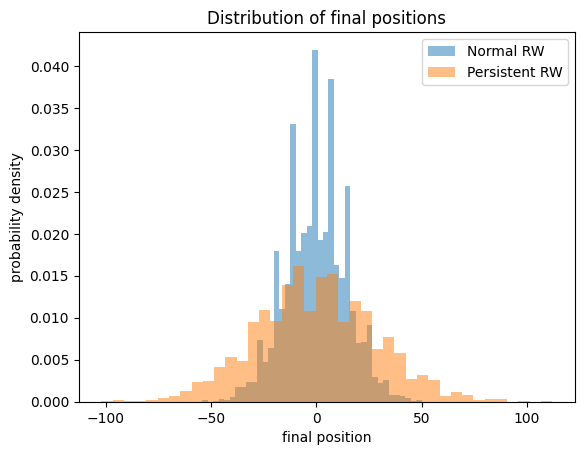

In [ ]:
T = 200
N = 5000

final_normal = []
final_persistent = []

for i in range(N):
    final_normal.append(normal_random_walk(T))
    final_persistent.append(persistent_random_walk(T, p_same=0.8))

plt.hist(final_normal, bins=40, alpha=0.5, density=True, label="Normal RW")
plt.hist(final_persistent, bins=40, alpha=0.5, density=True, label="Persistent RW")
plt.xlabel("final position")
plt.ylabel("probability density")
plt.title("Distribution of final positions")
plt.legend()
plt.show()

ステップの相関を見る

In [ ]:
def step_correlation(steps):
    steps = np.array(steps)
    return np.mean(steps[:-1] * steps[1:])

print("Normal RW step correlation:")
print(step_correlation(steps_normal))

print("Persistent RW step correlation:")
print(step_correlation(steps_persistent))

Normal RW step correlation:
-0.05527638190954774
Persistent RW step correlation:
0.507537688442211


アニメーションで比較する

In [ ]:
T = 120
p_same = 0.8

# 普通RW
x = 0
x_normal = [x]
for t in range(T):
    step = np.random.choice([-1, 1])
    x += step
    x_normal.append(x)

# 慣性付きRW
x = 0
prev_step = np.random.choice([-1, 1])
x_persistent = [x]

for t in range(T):
    if np.random.rand() < p_same:
        step = prev_step
    else:
        step = -prev_step

    x += step
    x_persistent.append(x)
    prev_step = step

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))

min_x = min(min(x_normal), min(x_persistent)) - 5
max_x = max(max(x_normal), max(x_persistent)) + 5

ax.set_xlim(min_x, max_x)
ax.set_ylim(-1, 2)
ax.set_yticks([0, 1])
ax.set_yticklabels(["Normal", "Persistent"])
ax.set_xlabel("position")
ax.set_title("Random walk animation")

point_normal, = ax.plot([], [], "o", markersize=10, label="Normal RW")
point_persistent, = ax.plot([], [], "o", markersize=10, label="Persistent RW")

trace_normal, = ax.plot([], [], "-", alpha=0.5)
trace_persistent, = ax.plot([], [], "-", alpha=0.5)

time_text = ax.text(0.02, 0.9, "", transform=ax.transAxes)

def init():
    point_normal.set_data([], [])
    point_persistent.set_data([], [])
    trace_normal.set_data([], [])
    trace_persistent.set_data([], [])
    time_text.set_text("")
    return point_normal, point_persistent, trace_normal, trace_persistent, time_text

def update(frame):
    point_normal.set_data([x_normal[frame]], [0])
    point_persistent.set_data([x_persistent[frame]], [1])

    trace_normal.set_data(x_normal[:frame+1], [0] * (frame+1))
    trace_persistent.set_data(x_persistent[:frame+1], [1] * (frame+1))

    time_text.set_text(f"time = {frame}")
    return point_normal, point_persistent, trace_normal, trace_persistent, time_text

ani = FuncAnimation(
    fig,
    update,
    frames=T+1,
    init_func=init,
    interval=80,
    blit=True
)

plt.close(fig)
HTML(ani.to_jshtml())

現在位置だけでは足りないことを確認する

In [ ]:
T = 10000
p_same = 0.8

x = 0
prev_step = np.random.choice([-1, 1])

positions = [x]
steps = []

for t in range(T):
    if np.random.rand() < p_same:
        step = prev_step
    else:
        step = -prev_step

    x += step

    positions.append(x)
    steps.append(step)
    prev_step = step

In [ ]:
target_x = 0

count_prev_plus = 0
count_prev_minus = 0

next_plus_after_prev_plus = 0
next_plus_after_prev_minus = 0

for t in range(1, T):
    if positions[t] == target_x:
        prev = steps[t-1]
        next_step = steps[t]

        if prev == 1:
            count_prev_plus += 1
            if next_step == 1:
                next_plus_after_prev_plus += 1
        else:
            count_prev_minus += 1
            if next_step == 1:
                next_plus_after_prev_minus += 1

print("現在位置 x=0 にいる場合だけを見る")
print()

print("前回の移動が +1 だった回数:", count_prev_plus)
print("その次も +1 だった割合:",
      next_plus_after_prev_plus / count_prev_plus)

print()

print("前回の移動が -1 だった回数:", count_prev_minus)
print("その次が +1 だった割合:",
      next_plus_after_prev_minus / count_prev_minus)

現在位置 x=0 にいる場合だけを見る

前回の移動が +1 だった回数: 11
その次も +1 だった割合: 0.8181818181818182

前回の移動が -1 だった回数: 10
その次が +1 だった割合: 0.1


状態を増やす

In [ ]:
states = []

for t in range(T):
    state = (positions[t], steps[t-1] if t > 0 else None)
    states.append(state)

print(states[:20])

[(0, None), (np.int64(1), np.int64(1)), (np.int64(2), np.int64(1)), (np.int64(3), np.int64(1)), (np.int64(4), np.int64(1)), (np.int64(5), np.int64(1)), (np.int64(6), np.int64(1)), (np.int64(7), np.int64(1)), (np.int64(8), np.int64(1)), (np.int64(7), np.int64(-1)), (np.int64(8), np.int64(1)), (np.int64(9), np.int64(1)), (np.int64(10), np.int64(1)), (np.int64(11), np.int64(1)), (np.int64(12), np.int64(1)), (np.int64(13), np.int64(1)), (np.int64(14), np.int64(1)), (np.int64(15), np.int64(1)), (np.int64(16), np.int64(1)), (np.int64(17), np.int64(1))]


In [ ]:
print("普通のランダムウォークでは、状態はだいたい")
print("state = x")
print()

print("慣性付きランダムウォークでは、現在位置だけでは足りない")
print("state = (x, previous_step)")
print()

print("つまり、状態を増やすと Markov 的に見られる")

普通のランダムウォークでは、状態はだいたい
state = x

慣性付きランダムウォークでは、現在位置だけでは足りない
state = (x, previous_step)

つまり、状態を増やすと Markov 的に見られる
